# Low-Rank vs Full GRF Kernel

In [ ]:
num_nodes = 2**12
max_walk_length = 4
proj_dims = [1]
while proj_dims[-1] <= num_nodes:
    proj_dims.append(proj_dims[-1] * 2)
jlt_seed = 0
modulation = [1.0, 0.6, -0.3, 0.15]

In [9]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

root = Path.cwd()
if not (root / "src").exists():
    root = root.parent
sys.path.insert(0, str(root / "src"))

from grf_gp.kernels.general import GeneralGRFKernel, GeneralLowRankGRFKernel

In [10]:
adjacency = torch.zeros(num_nodes, num_nodes)
for i in range(num_nodes - 1):
    adjacency[i, i + 1] = 1.0
    adjacency[i + 1, i] = 1.0
adjacency += torch.eye(num_nodes)
transition = adjacency / adjacency.sum(dim=1, keepdim=True)
rw_mats = [torch.linalg.matrix_power(transition, t) for t in range(max_walk_length)]
modulation = torch.tensor(modulation)

full_kernel = GeneralGRFKernel(rw_mats=rw_mats, max_walk_length=max_walk_length)
with torch.no_grad():
    full_kernel.raw_modulation_function.copy_(modulation)

full_gram = full_kernel.forward()
full_norm = torch.linalg.norm(full_gram)

approx_grams = {}
errors = []

for proj_dim in proj_dims:
    kernel = GeneralLowRankGRFKernel(
        rw_mats=rw_mats,
        max_walk_length=max_walk_length,
        proj_dim=proj_dim,
        jlt_seed=jlt_seed,
    )
    with torch.no_grad():
        kernel.raw_modulation_function.copy_(modulation)

    gram = kernel.forward()
    diff = gram - full_gram
    approx_grams[proj_dim] = gram
    errors.append((torch.linalg.norm(diff) / full_norm).item())

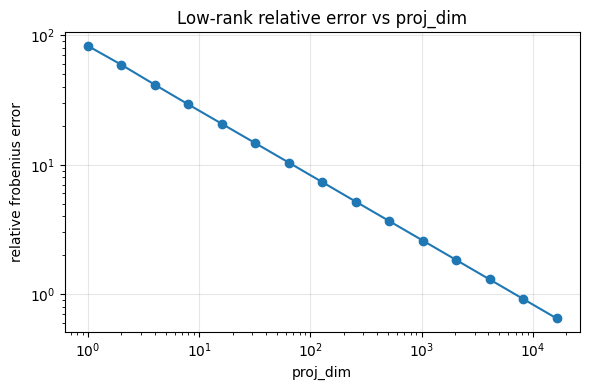

In [11]:
plt.figure(figsize=(6, 4))
plt.plot(proj_dims, errors, marker="o")
plt.xlabel("proj_dim")
plt.ylabel("relative frobenius error")
plt.xscale('log')
plt.yscale('log')
plt.title("Low-rank relative error vs proj_dim")
plt.grid(True, alpha=0.3)
plt.tight_layout()